<a href="https://colab.research.google.com/github/Risspecct/Medify/blob/dev/backend/Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle

In [ ]:
df = pd.read_csv("Prediction.csv")

In [ ]:
df.isnull().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
...,...
hip weakness,1
back swelling,1
ankle stiffness or tightness,1
ankle weakness,1


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
print("df shape:",df.shape)
for c in df.columns:
  print(c)

df shape: (14940, 378)
diseases
anxiety and nervousness
depression
shortness of breath
depressive or psychotic symptoms
sharp chest pain
dizziness
insomnia
abnormal involuntary movements
chest tightness
palpitations
irregular heartbeat
breathing fast
hoarse voice
sore throat
difficulty speaking
cough
nasal congestion
throat swelling
diminished hearing
lump in throat
throat feels tight
difficulty in swallowing
skin swelling
retention of urine
groin mass
leg pain
hip pain
suprapubic pain
blood in stool
lack of growth
emotional symptoms
elbow weakness
back weakness
pus in sputum
symptoms of the scrotum and testes
swelling of scrotum
pain in testicles
flatulence
pus draining from ear
jaundice
mass in scrotum
white discharge from eye
irritable infant
abusing alcohol
fainting
hostile behavior
drug abuse
sharp abdominal pain
feeling ill
vomiting
headache
nausea
diarrhea
vaginal itching
vaginal dryness
painful urination
involuntary urination
pain during intercourse
frequent urination
lower abd

#Training + Test

In [ ]:
encoder = LabelEncoder()
df['diseases'] = encoder.fit_transform(df['diseases'])

X = df.drop('diseases', axis=1) # The 0/1 symptom columns
y = df['diseases']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
def get_prediction(user_input_symptoms, model, encoder, symptom_columns):
    """
    user_input_symptoms: List of strings (e.g., ['fever', 'cough'])
    model: Trained RandomForest
    encoder: Trained LabelEncoder
    symptom_columns: List of all symptom column names (X.columns)
    """

    # 1. Prepare Input Vector
    input_vector = np.zeros(len(symptom_columns))
    for s in user_input_symptoms:
        if s in symptom_columns:
            index = symptom_columns.get_loc(s)
            input_vector[index] = 1
        else:
            print(f"Warning: Symptom '{s}' not recognized by model.")

    # 2. Get Probabilities
    probabilities = model.predict_proba([input_vector])[0]

    # 3. Thresholding (Handle "Inconclusive" cases)
    # If the highest probability is below 20%, the model is just guessing.
    MAX_PROB_THRESHOLD = 0.20
    if max(probabilities) < MAX_PROB_THRESHOLD:
        return {
            "status": "Inconclusive",
            "message": "The symptoms provided are too vague or uncommon. Please provide more details or consult a professional.",
            "results": []
        }

    # 4. Get Top 3 Indices
    top_3_idx = np.argsort(probabilities)[-3:][::-1]

    results = []
    for i in top_3_idx:
        prob = probabilities[i]
        disease_name = encoder.classes_[i]

        # 5. Assign Confidence Labels
        if prob > 0.70:
            confidence = "High"
        elif prob > 0.40:
            confidence = "Medium"
        else:
            confidence = "Low"

        results.append({
            "disease": disease_name,
            "probability": f"{prob * 100:.1f}%",
            "confidence": confidence
        })

    return {
        "status": "Success",
        "results": results
    }

In [ ]:
# User selects symptoms from a checkbox/dropdown
user_symptoms = ['chills', 'vomiting', 'fever', 'sweating']

output = get_prediction(user_symptoms, model, encoder, X.columns)

if output['status'] == 'Success':
    print(f"--- Potential Diagnoses ---")
    for res in output['results']:
        # Color coding or icons in a UI would look great here
        print(f"[{res['confidence']}] {res['disease']}: {res['probability']}")
else:
    print(output['message'])

--- Potential Diagnoses ---
[Medium] choledocholithiasis: 44.0%
[Low] asthma: 22.0%
[Low] teething syndrome: 18.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#Evaluation

### Evaluation of Random Forest


Overall Accuracy: 97.89%

Classification Report:
                                  precision    recall  f1-score   support

              acute pancreatitis       0.98      0.99      0.99       242
                          asthma       0.99      0.99      0.99       169
                     atelectasis       1.00      1.00      1.00        13
              atrophic vaginitis       0.94      0.98      0.96        59
  cellulitis or abscess of mouth       1.00      1.00      1.00        33
             choledocholithiasis       0.99      0.96      0.97        77
           chronic pain disorder       0.95      0.95      0.95       110
                       cirrhosis       1.00      1.00      1.00        58
                  cryptorchidism       1.00      1.00      1.00         1
                   cysticercosis       1.00      1.00      1.00         4
            diabetic retinopathy       0.92      0.95      0.93        97
                 eating disorder       0.97      0.99      0.9

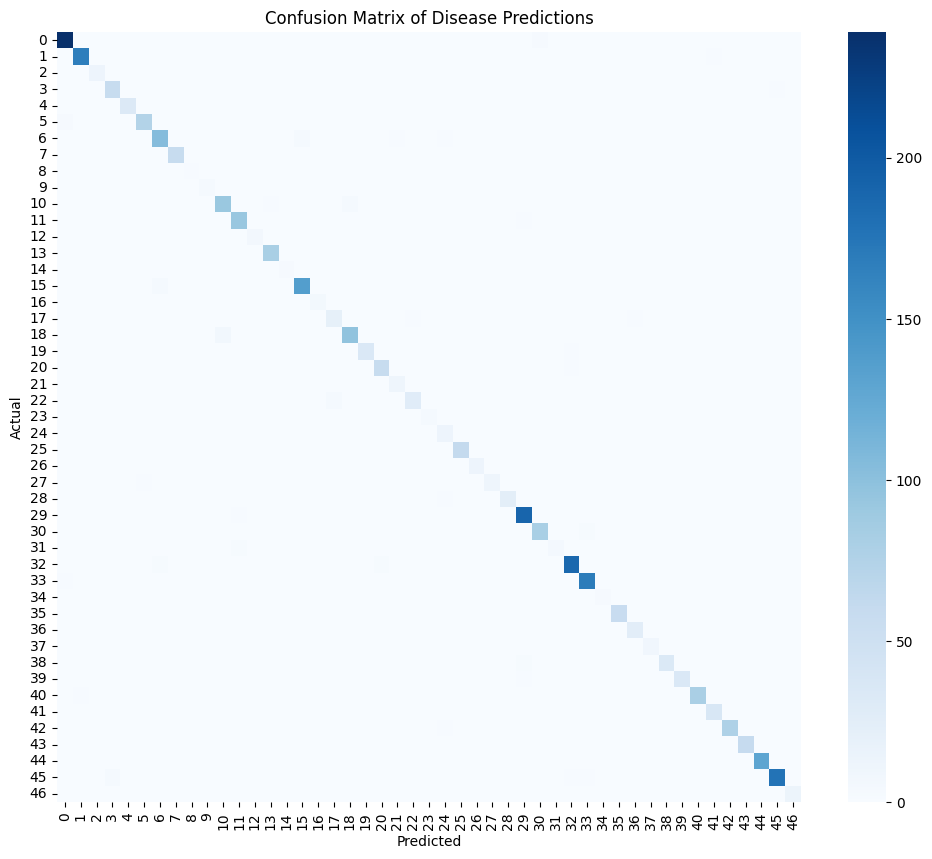

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions for the test set
y_pred = model.predict(X_test)

# 2. Basic Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# 3. Precision, Recall, F1-Score
# 'weighted' handles the fact that some diseases might have more samples than others
print("\nClassification Report:")

# Get the unique labels present in the test set
unique_labels_in_test = np.unique(y_test)
# Map these unique labels back to their original disease names using the encoder
target_names_for_report = encoder.inverse_transform(unique_labels_in_test)

print(classification_report(y_test, y_pred, labels=unique_labels_in_test, target_names=target_names_for_report))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues') # annot=False if you have many diseases
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Disease Predictions')
plt.show()

###Evaluating `get_prediction` function

In [ ]:
evaluation_results = []

# Loop through the test set. It's more efficient to iterate over indices.
for i in range(len(X_test)):
    # Get the symptoms for the current test sample
    test_symptoms_vector = X_test.iloc[i]
    # Extract only the symptoms that are present (value = 1)
    present_symptoms = test_symptoms_vector[test_symptoms_vector == 1].index.tolist()

    # Get the predicted output from your function
    prediction_output = get_prediction(present_symptoms, model, encoder, X.columns)

    # Get the true disease name for the current test sample
    true_disease_encoded = y_test.iloc[i]
    true_disease_name = encoder.classes_[true_disease_encoded]

    evaluation_results.append({
        'true_disease': true_disease_name,
        'prediction_output': prediction_output
    })

print(f"Collected {len(evaluation_results)} evaluation results.")
# Display the first few results to check the structure
import json
print("First 5 evaluation results:")
print(json.dumps(evaluation_results[:5], indent=2))

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi

Collected 2988 evaluation results.
First 5 evaluation results:
[
  {
    "true_disease": "pyelonephritis",
    "prediction_output": {
      "status": "Success",
      "results": [
        {
          "disease": "pyelonephritis",
          "probability": "100.0%",
          "confidence": "High"
        },
        {
          "disease": "vocal cord polyp",
          "probability": "0.0%",
          "confidence": "Low"
        },
        {
          "disease": "turner syndrome",
          "probability": "0.0%",
          "confidence": "Low"
        }
      ]
    }
  },
  {
    "true_disease": "vaginitis",
    "prediction_output": {
      "status": "Success",
      "results": [
        {
          "disease": "vaginitis",
          "probability": "99.5%",
          "confidence": "High"
        },
        {
          "disease": "atrophic vaginitis",
          "probability": "0.5%",
          "confidence": "Low"
        },
        {
          "disease": "turner syndrome",
          "probabili

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [ ]:
# Initialize counters
total_samples = len(evaluation_results)
top1_correct = 0
top3_correct = 0
inconclusive_count = 0

# Detailed confidence tracking for true disease if predicted
confidence_counts = {
    'High': 0,
    'Medium': 0,
    'Low': 0
}

for entry in evaluation_results:
    true_disease = entry['true_disease']
    prediction_output = entry['prediction_output']

    if prediction_output['status'] == 'Inconclusive':
        inconclusive_count += 1
        continue # Skip to the next sample if inconclusive

    predicted_results = prediction_output['results']

    # Check for Top-1 accuracy
    if predicted_results and predicted_results[0]['disease'] == true_disease:
        top1_correct += 1

    # Check for Top-3 accuracy and confidence
    found_in_top3 = False
    for i, res in enumerate(predicted_results):
        if res['disease'] == true_disease:
            found_in_top3 = True
            if i < 3: # Ensure it's within the top 3 (0-indexed)
                top3_correct += 1
            confidence_counts[res['confidence']] += 1
            break

# Calculate metrics
top1_accuracy = (top1_correct / (total_samples - inconclusive_count)) * 100 if (total_samples - inconclusive_count) > 0 else 0
top3_accuracy = (top3_correct / (total_samples - inconclusive_count)) * 100 if (total_samples - inconclusive_count) > 0 else 0
inconclusive_rate = (inconclusive_count / total_samples) * 100

print(f"--- Evaluation of `get_prediction` Function ---")
print(f"Total Samples: {total_samples}")
print(f"Inconclusive Rate: {inconclusive_rate:.2f}%")
print(f"\nConsidering only conclusive predictions ({total_samples - inconclusive_count} samples):")
print(f"Top-1 Accuracy: {top1_accuracy:.2f}%")
print(f"Top-3 Accuracy: {top3_accuracy:.2f}%")
print(f"\nConfidence distribution for correctly predicted true diseases:")
for conf, count in confidence_counts.items():
    print(f"  {conf}: {count} ({count / top3_correct * 100 if top3_correct > 0 else 0:.2f}%) Confirmed in Top-3")


--- Evaluation of `get_prediction` Function ---
Total Samples: 2988
Inconclusive Rate: 0.00%

Considering only conclusive predictions (2988 samples):
Top-1 Accuracy: 97.89%
Top-3 Accuracy: 99.93%

Confidence distribution for correctly predicted true diseases:
  High: 2866 (95.98%) Confirmed in Top-3
  Medium: 68 (2.28%) Confirmed in Top-3
  Low: 52 (1.74%) Confirmed in Top-3


#Exporting in Pickle

In [ ]:
import pickle

# Create a dictionary to store everything you need
model_assets = {
    "model": model,          # Your trained RandomForest
    "encoder": encoder,      # Your LabelEncoder
    "symptom_list": list(X.columns) # The EXACT list of symptoms in order
}

# Save it to a file
with open('disease_model.pkl', 'wb') as f:
    pickle.dump(model_assets, f)

print("Model exported successfully!")

Model exported successfully!
